In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("cardekho_dataset.csv")
print(df.head())
print(df.shape)
print(f"Columns: {df.columns.tolist()}")

   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1         550000  
2         2

In [2]:
df = df.drop(columns = ['Unnamed: 0','car_name','model'])

In [3]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15411 non-null  object 
 1   vehicle_age        15411 non-null  int64  
 2   km_driven          15411 non-null  int64  
 3   seller_type        15411 non-null  object 
 4   fuel_type          15411 non-null  object 
 5   transmission_type  15411 non-null  object 
 6   mileage            15411 non-null  float64
 7   engine             15411 non-null  int64  
 8   max_power          15411 non-null  float64
 9   seats              15411 non-null  int64  
 10  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.3+ MB


In [5]:
df['seller_type'].value_counts()

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

In [6]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [7]:
df['transmission_type'].value_counts()

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

In [8]:
len(df['brand'].unique())

32

In [9]:
counts = df['brand'].value_counts()
counts[counts < 100]

brand
Jaguar          59
Land Rover      51
Jeep            41
Kia             32
Porsche         21
Volvo           20
MG              19
Mini            17
Nissan          11
Lexus           10
Isuzu            8
Bentley          3
Maserati         2
ISUZU            2
Ferrari          1
Mercedes-AMG     1
Rolls-Royce      1
Force            1
Name: count, dtype: int64

In [10]:
df = pd.get_dummies(df, columns=['brand','seller_type','fuel_type','transmission_type'], drop_first=True)
df.shape

(15411, 45)

In [80]:
# Check the new columns created after get_dummies
for c in df.columns:
    if '_' in c:
        print(c)

vehicle_age
km_driven
max_power
selling_price
brand_BMW
brand_Bentley
brand_Datsun
brand_Ferrari
brand_Force
brand_Ford
brand_Honda
brand_Hyundai
brand_ISUZU
brand_Isuzu
brand_Jaguar
brand_Jeep
brand_Kia
brand_Land Rover
brand_Lexus
brand_MG
brand_Mahindra
brand_Maruti
brand_Maserati
brand_Mercedes-AMG
brand_Mercedes-Benz
brand_Mini
brand_Nissan
brand_Porsche
brand_Renault
brand_Rolls-Royce
brand_Skoda
brand_Tata
brand_Toyota
brand_Volkswagen
brand_Volvo
seller_type_Individual
seller_type_Trustmark Dealer
fuel_type_Diesel
fuel_type_Electric
fuel_type_LPG
fuel_type_Petrol
transmission_type_Manual


In [81]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True


In [82]:
X = df.drop(columns = ['selling_price'])
y = df['selling_price']
print(f"Features: {X.shape[0]} rows × {X.shape[1]} columns")
print(f"Target: selling_price — ₹{y.min():,} to ₹{y.max():,}")
print(f"Target mean: ₹{y.mean():,.0f}, median: ₹{y.median():,.0f}")
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Features: 15411 rows × 44 columns
Target: selling_price — ₹40,000 to ₹39,500,000
Target mean: ₹774,971, median: ₹556,000
Train: 12328 rows (80%)
Test:  3083 rows (20%)


In [83]:
num_cols = X.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'], dtype='object')

In [84]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
X_train.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
1347,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True
10363,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
316,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
10638,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [85]:
X_train['mileage'].std()

1.00004056054677

In [86]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Model trained
Coefficients: [-2.27679116e+05 -4.61441160e+04 -1.61215737e+04  7.81262973e+04
  3.35373847e+05  3.61447730e+04  4.05858369e+05  3.66129519e+06
 -7.09797494e+05  3.35712157e+07 -6.84161881e+05 -6.05929376e+05
 -6.34461348e+05 -5.81777427e+05 -5.39248828e+05 -6.72399952e+05
  3.89829810e+05 -3.30328774e+05 -1.88217266e+05  1.37973826e+06
  2.43851701e+06 -3.34953252e+05 -7.57351045e+05 -5.09629233e+05
  3.05324950e+06 -9.31322575e-09  2.12192715e+05  5.81734336e+05
 -6.92637218e+05  1.83113118e+06 -6.41815125e+05  1.83478941e+07
 -6.76533456e+05 -8.25722441e+05 -4.17293997e+05 -6.20822305e+05
  1.07324564e+06 -1.20906369e+04 -8.11214717e+04  4.90755661e+04
  2.93031384e+05  2.77714921e+05 -4.11245704e+04 -5.92492214e+04]
Intercept: 1324658.8210497994


In [87]:
np.set_printoptions(suppress=True) # without scientific notation

In [88]:
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients: [ -227679.11587519   -46144.11602343   -16121.5737091     78126.29726954
   335373.84695452    36144.77304341   405858.36913187  3661295.18698692
  -709797.4940396  33571215.66884789  -684161.88083796  -605929.37605712
  -634461.34788649  -581777.42689462  -539248.82753071  -672399.95215525
   389829.81044752  -330328.77365905  -188217.26586087  1379738.25866929
  2438517.01280427  -334953.25202865  -757351.04477398  -509629.23318773
  3053249.50497522       -0.00000001   212192.71541427   581734.3357143
  -692637.21807699  1831131.18066438  -641815.12545297 18347894.067448
  -676533.45597994  -825722.44119243  -417293.9974245   -620822.30464372
  1073245.63550855   -12090.63690008   -81121.47169078    49075.56610445
   293031.384222     277714.92116462   -41124.570408     -59249.22137013]
Intercept: 1324658.8210497994


In [89]:
y_pred = model.predict(X_train)
print(X_train[:5])
print(y_pred[:5])

       vehicle_age  km_driven  ...  fuel_type_Petrol  transmission_type_Manual
11210     0.323969   0.349100  ...             False                     False
1347     -1.337798  -1.069394  ...              True                      True
10363    -1.337798  -1.163564  ...             False                     False
316       0.323969   0.178369  ...              True                      True
10638     1.321030   0.585469  ...              True                      True

[5 rows x 44 columns]
[3412193.03734086  538816.57194792 3107972.2792696   635541.46234088
   86297.34208784]


In [90]:
df.loc[[11210,1347,10363,316,10638]]

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,7,70252,11.20,2400,215.0,5,1825000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
1347,2,10000,23.84,1199,84.0,5,515000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True
10363,2,6000,19.00,1950,241.3,5,7500000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
316,7,63000,17.80,1497,117.3,5,435000,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
10638,10,80292,20.36,1197,78.9,5,200000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [91]:
mae = mean_absolute_error(y_train, y_pred)
mae

199219.72900407415

In [92]:
err = np.mean(np.abs(y_train - y_pred))
err

199219.72900407415

In [93]:
mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 199219.73
Mean Squared Error: 160929270640.31
R² Score: 0.8016


In [95]:
y_test_pred = model.predict(X_test)
y_test_pred[:5]

array([ -57120.86315061,  656767.14892569,  631434.59648899,
       1226271.22317596, -210649.19946355])

In [96]:
X_test[:5]

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.985737,0.413795,0.149668,-0.550917,-0.502047,-0.403824,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
10928,-0.673091,0.060655,1.838470,-0.453086,-0.616670,-0.403824,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True
2518,0.323969,0.955277,0.248161,-0.453086,-0.271396,2.070500,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
11322,-1.670152,-1.198878,-0.321179,0.026483,0.444184,-0.403824,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
9394,1.653383,0.154826,-0.008882,-1.320145,-1.264645,-0.403824,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [99]:
y_test[:5]

3334      190000
10928     600000
2518      665000
11322    1570000
9394      160000
Name: selling_price, dtype: int64

In [100]:
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
print(f"Test Mean Absolute Error: {mae:.2f}")
print(f"Test Root Mean Squared Error: {rmse:.2f}")
print(f"Test R² Score: {r2:.4f}")

Test Mean Absolute Error: 212761.44
Test Root Mean Squared Error: 445800.72
Test R² Score: 0.7360


In [101]:
val = df['selling_price'].mean()
df['base_pred'] = val
base_mae = mean_absolute_error(df['selling_price'], df['base_pred'])
base_mae

452669.921078294

In [104]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
coef_df['Abs_coff'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_coff', ascending = False)
coef_df

,Feature,Coefficient,Abs_coff
9,brand_Ferrari,3.357122e+07,3.357122e+07
31,brand_Rolls-Royce,1.834789e+07,1.834789e+07
7,brand_Bentley,3.661295e+06,3.661295e+06
24,brand_Maserati,3.053250e+06,3.053250e+06
20,brand_Lexus,2.438517e+06,2.438517e+06
29,brand_Porsche,1.831131e+06,1.831131e+06
19,brand_Land Rover,1.379738e+06,1.379738e+06
36,brand_Volvo,1.073246e+06,1.073246e+06
33,brand_Tata,-8.257224e+05,8.257224e+05
22,brand_Mahindra,-7.573510e+05,7.573510e+05


In [110]:
print("Top 15 Most Impactful Features (by coefficient magnitude):")
print("=" * 65)
for _, row in coef_df.head(15).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    bar_len = int(row['Abs_coff'] / coef_df['Abs_coff'].max() * 30)
    bar = "█" * bar_len
    print(f"  {direction} {row['Feature']:30s} {bar} ({row['Coefficient']:>+12,.0f})")

print(f"\n  Intercept: ₹{model.intercept_:,.0f}")

Top 15 Most Impactful Features (by coefficient magnitude):
  ↑ brand_Ferrari                  ██████████████████████████████ ( +33,571,216)
  ↑ brand_Rolls-Royce              ████████████████ ( +18,347,894)
  ↑ brand_Bentley                  ███ (  +3,661,295)
  ↑ brand_Maserati                 ██ (  +3,053,250)
  ↑ brand_Lexus                    ██ (  +2,438,517)
  ↑ brand_Porsche                  █ (  +1,831,131)
  ↑ brand_Land Rover               █ (  +1,379,738)
  ↑ brand_Volvo                     (  +1,073,246)
  ↓ brand_Tata                      (    -825,722)
  ↓ brand_Mahindra                  (    -757,351)
  ↓ brand_Datsun                    (    -709,797)
  ↓ brand_Nissan                    (    -692,637)
  ↓ brand_Force                     (    -684,162)
  ↓ brand_Skoda                     (    -676,533)
  ↓ brand_Isuzu                     (    -672,400)

  Intercept: ₹1,324,659


In [114]:
sample = X_test.index[0]
sample


3334

In [117]:
sample_features = X_test.loc[sample]
sample_actual = y_test.loc[sample]
sample_actual

190000

In [118]:
predict = model.predict(X_test.loc[[sample]])[0]
predict

-57120.863150609424

In [126]:
sample_features

vehicle_age                     1.985737
km_driven                       0.413795
mileage                         0.149668
engine                         -0.550917
max_power                      -0.502047
seats                          -0.403824
brand_BMW                          False
brand_Bentley                      False
brand_Datsun                       False
brand_Ferrari                      False
brand_Force                        False
brand_Ford                         False
brand_Honda                        False
brand_Hyundai                       True
brand_ISUZU                        False
brand_Isuzu                        False
brand_Jaguar                       False
brand_Jeep                         False
brand_Kia                          False
brand_Land Rover                   False
brand_Lexus                        False
brand_MG                           False
brand_Mahindra                     False
brand_Maruti                       False
brand_Maserati  

In [125]:
contributions = []
for feature, value in sample_features.items():
    coef = model.coef_[list(X_train.columns).index(feature)]
    cont = coef*value
    contributions.append((feature, value, coef, cont))
for i in contributions:
    print(i)

('vehicle_age', 1.9857368532491522, -227679.11587518512, -452110.8111085392)
('km_driven', 0.4137954453676014, -46144.1160234314, -19094.225041010068)
('mileage', 0.14966790175177855, -16121.573709103988, -2412.8821099782317)
('engine', -0.5509174225989446, 78126.29726953761, -43041.138328932626)
('max_power', -0.5020465790486293, 335373.8469545189, -168373.29256589475)
('seats', -0.40382371071387335, 36144.773043413916, -14596.11637330219)
('brand_BMW', False, 405858.36913186713, 0.0)
('brand_Bentley', False, 3661295.186986919, 0.0)
('brand_Datsun', False, -709797.4940396023, -0.0)
('brand_Ferrari', False, 33571215.66884789, 0.0)
('brand_Force', False, -684161.8808379557, -0.0)
('brand_Ford', False, -605929.3760571154, -0.0)
('brand_Honda', False, -634461.3478864925, -0.0)
('brand_Hyundai', True, -581777.4268946234, -581777.4268946234)
('brand_ISUZU', False, -539248.8275307091, -0.0)
('brand_Isuzu', False, -672399.9521552544, -0.0)
('brand_Jaguar', False, 389829.81044751714, 0.0)
('br

In [128]:
list(X_train.columns).index('vehicle_age')

0

# new after 1st cell

In [2]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [2]:
df = df.drop(columns=['Unnamed: 0','car_name','model'])
# one hot encoding
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type','transmission_type'], drop_first = True)
# separate
X = df.drop(columns=['selling_price'])
y = df['selling_price']
# split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [3]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"train: {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"test: {X_test.shape[0]} rows, {X_test.shape[1]} columns")

train: 12328 rows, 44 columns
test: 3083 rows, 44 columns


In [5]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_train_pred = ols.predict(X_train)
y_test_pred = ols.predict(X_test)

ols_train_mae = mean_absolute_error(y_train, y_train_pred)
ols_test_mae = mean_absolute_error(y_test, y_test_pred)
ols_train_r2 = r2_score(y_train, y_train_pred)
ols_test_r2 = r2_score(y_test, y_test_pred)
print('=' * 40)
print("Ols Regression Performance:")
print(f"Train MAE: {ols_train_mae}")
print(f"Test MAE: {ols_test_mae}")
print(f"Train R2: {ols_train_r2}")
print(f"Test R2: {ols_test_r2}")

Ols Regression Performance:
Train MAE: 199219.72900407415
Test MAE: 212761.44410581293
Train R2: 0.8015753782439603
Test R2: 0.7359948378848244


In [7]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
ridge_alp = Ridge(alpha = 1.0)
ridge_alp.fit(X_train, y_train)

y_tr = ridge_alp.predict(X_train)
y_te = ridge_alp.predict(X_test)

ridge_train_mae = mean_absolute_error(y_train, y_tr)
ridge_test_mae = mean_absolute_error(y_test, y_te)
print('=' * 40)
print("Ridge Regression Performance:")
print(f"Train MAE: {ridge_train_mae}")
print(f"Test MAE: {ridge_test_mae}")
print(f"Train R2: {r2_score(y_train, y_tr)}")
print(f"Test R2: {r2_score(y_test, y_te)}")

Ridge Regression Performance:
Train MAE: 210894.2401364602
Test MAE: 220956.15996696142
Train R2: 0.7642428859972734
Test R2: 0.7365715780232374


In [13]:
alphas = [0.01, 0.1, 0.9,1,1.1,10,100,500,1000,5000,10000,100000]
r2_values = []
mae_values = []
for a in alphas:
    print("*"*30)
    print()
    print(f"Alpha is set to: {a}")
    ridge_def = Ridge(alpha =a)
    ridge_def.fit(X_train, y_train)

    y_train_pred = ridge_def.predict(X_train)
    y_test_pred = ridge_def.predict(X_test)
    r2_values.append((r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)))
    mae_values.append((mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)))
    print('='*30)
    print(f'{"Ridge (α={a})":<15} {"Train":>15} {"Test":>15}')
    print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_train_pred)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_test_pred)):>15}')
    print(f'{"R²":<15} {r2_score(y_train, y_train_pred):>15.4f} {r2_score(y_test, y_test_pred):>15.4f}')
    print('=' * 55)

******************************

Alpha is set to: 0.01
Ridge (α={a})             Train            Test
MAE                    ₹199,396        ₹212,865
R²                       0.8016          0.7361
******************************

Alpha is set to: 0.1
Ridge (α={a})             Train            Test
MAE                    ₹200,942        ₹213,834
R²                       0.8003          0.7368
******************************

Alpha is set to: 0.9
Ridge (α={a})             Train            Test
MAE                    ₹210,146        ₹220,387
R²                       0.7679          0.7368
******************************

Alpha is set to: 1
Ridge (α={a})             Train            Test
MAE                    ₹210,894        ₹220,956
R²                       0.7642          0.7366
******************************

Alpha is set to: 1.1
Ridge (α={a})             Train            Test
MAE                    ₹211,585        ₹221,495
R²                       0.7607          0.7364
****************

In [14]:
r2_values

[(0.8015596343343795, 0.7360923974619404),
 (0.8002645991170924, 0.7367581381647799),
 (0.7679463088458047, 0.7367687888971604),
 (0.7642428859972734, 0.7365715780232374),
 (0.7607366183138613, 0.7363681127163253),
 (0.6823736218091631, 0.7250696356897076),
 (0.6495822200580555, 0.7008184131423185),
 (0.637107577193436, 0.6864195612645012),
 (0.6302664446411541, 0.6792817911994116),
 (0.586207277071829, 0.6349410160533622),
 (0.5353743513926588, 0.5829697312171602),
 (0.19842967059991967, 0.21879629412764734)]

# alpha tuning curves

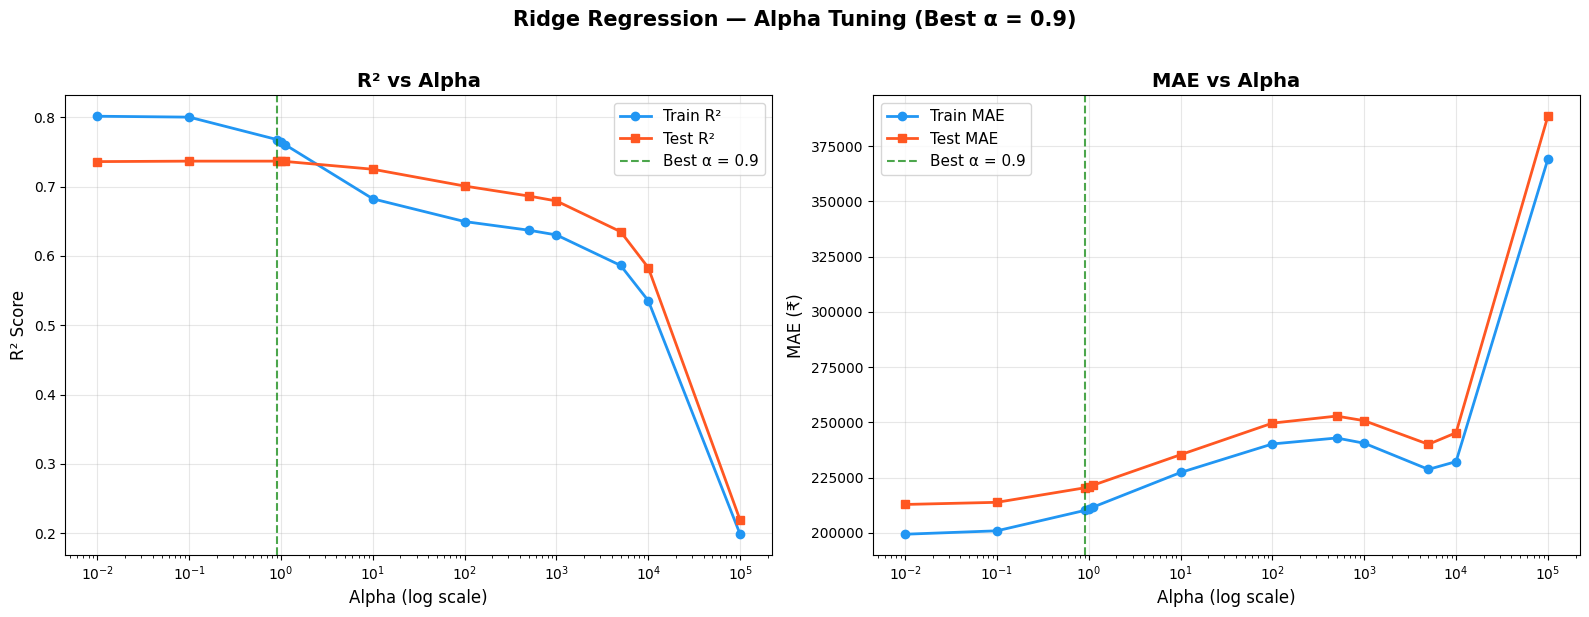

In [16]:
import numpy as np
import matplotlib.pyplot as plt
alphas = [0.01, 0.1, 0.9,1,1.1,10,100,500,1000,5000,10000,100000]
r2_values = []
mae_values = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_tr = ridge.predict(X_train)
    y_te = ridge.predict(X_test)
    r2_values.append((r2_score(y_train, y_tr), r2_score(y_test, y_te)))
    mae_values.append((mean_absolute_error(y_train, y_tr), mean_absolute_error(y_test, y_te)))
r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)
best_idx = np.argmax(r2_test)
best_alpha = alphas[best_idx]
fig, axes = plt.subplots(1,2, figsize=(16,6))
# ── R² Plot ──
axes[0].plot(alphas, r2_train, 'o-', label='Train R²', color='#2196F3', linewidth=2)
axes[0].plot(alphas, r2_test, 's-', label='Test R²', color='#FF5722', linewidth=2)
axes[0].axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── MAE Plot ──
axes[1].plot(alphas, mae_train, 'o-', label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(alphas, mae_test, 's-', label='Test MAE', color='#FF5722', linewidth=2)
axes[1].axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('MAE (₹)', fontsize=12)
axes[1].set_title('MAE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.suptitle(f'Ridge Regression — Alpha Tuning (Best α = {best_alpha})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [17]:
r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)
best_idx = np.argmax(r2_test)
best_alp = alphas[best_idx]
print(best_alp)

0.9


In [18]:
best_ridge_model = Ridge(alpha=0.9)
best_ridge_model.fit(X_train, y_train)


models = {
    'OLS': ols,
    f"Ridge (α=0.9)": best_ridge_model,
}

print('=' * 70)
print(f'{"Model":<25} {"Train MAE":>12} {"Test MAE":>12} {"Train R²":>10} {"Test R²":>10}')
print('=' * 70)

for name, model in models.items():
    tr_p = model.predict(X_train)
    te_p = model.predict(X_test)
    print(f'{name:<25} {"₹{:,.0f}".format(mean_absolute_error(y_train, tr_p)):>12} '
          f'{"₹{:,.0f}".format(mean_absolute_error(y_test, te_p)):>12} '
          f'{r2_score(y_train, tr_p):>10.4f} {r2_score(y_test, te_p):>10.4f}')

print('=' * 70)

Model                        Train MAE     Test MAE   Train R²    Test R²
OLS                           ₹199,220     ₹212,761     0.8016     0.7360
Ridge (α=0.9)                 ₹210,146     ₹220,387     0.7679     0.7368


In [19]:
coef_comparison = pd.DataFrame({
    "feature": X_train.columns,
    "OLS" : ols.coef_,
    "Ridge": best_ridge_model.coef_
})
coef_comparison

,feature,OLS,Ridge
0,vehicle_age,-2.276791e+05,-2.214393e+05
1,km_driven,-4.614412e+04,-4.665502e+04
2,mileage,-1.612157e+04,3.209866e+03
3,engine,7.812630e+04,8.321208e+04
4,max_power,3.353738e+05,4.270616e+05
5,seats,3.614477e+04,2.034332e+04
6,brand_BMW,4.058584e+05,1.896627e+05
7,brand_Bentley,3.661295e+06,1.980336e+06
8,brand_Datsun,-7.097975e+05,-6.639109e+05
9,brand_Ferrari,3.357122e+07,1.711292e+07


In [20]:
np.set_printoptions(suppress=True) # without scientific notation

In [21]:
coef_comparison

,feature,OLS,Ridge
0,vehicle_age,-2.276791e+05,-2.214393e+05
1,km_driven,-4.614412e+04,-4.665502e+04
2,mileage,-1.612157e+04,3.209866e+03
3,engine,7.812630e+04,8.321208e+04
4,max_power,3.353738e+05,4.270616e+05
5,seats,3.614477e+04,2.034332e+04
6,brand_BMW,4.058584e+05,1.896627e+05
7,brand_Bentley,3.661295e+06,1.980336e+06
8,brand_Datsun,-7.097975e+05,-6.639109e+05
9,brand_Ferrari,3.357122e+07,1.711292e+07


In [23]:
coef_comparison['OLS_abs'] = coef_comparison['OLS'].abs()
coef_comparison = coef_comparison.sort_values('OLS_abs', ascending=False).drop(columns='OLS_abs')

print('Top 15 Features — Coefficient Comparison (OLS vs Ridge)')
print('=' * 60)
print(f'{"Feature":<25} {"OLS":>15} {"Ridge":>15}')
print('-' * 60)

for _, row in coef_comparison.head(20).iterrows():
    shrink = abs(row['OLS']) - abs(row['Ridge'])
    marker = ' ← shrunk' if shrink > 100 else ''
    print(f'{row["feature"]:<25} {row["OLS"]:>15,.0f} {row["Ridge"]:>15,.0f}{marker}')

print('-' * 60)

Top 15 Features — Coefficient Comparison (OLS vs Ridge)
Feature                               OLS           Ridge
------------------------------------------------------------
brand_Ferrari                  33,571,216      17,112,922 ← shrunk
brand_Rolls-Royce              18,347,894       9,108,759 ← shrunk
brand_Bentley                   3,661,295       1,980,336 ← shrunk
brand_Maserati                  3,053,250       1,857,060 ← shrunk
brand_Lexus                     2,438,517       1,917,271 ← shrunk
brand_Porsche                   1,831,131       1,314,989 ← shrunk
brand_Land Rover                1,379,738       1,168,345 ← shrunk
brand_Volvo                     1,073,246         862,394 ← shrunk
brand_Tata                       -825,722        -854,366
brand_Mahindra                   -757,351        -736,494 ← shrunk
brand_Datsun                     -709,797        -663,911 ← shrunk
brand_Nissan                     -692,637        -692,308 ← shrunk
brand_Force                   

# cross validation

In [5]:
print("="*60)
mae_scores = []
for seed in range(0,40,2):
    Xt, Xv, yt, yv = train_test_split(X,y, test_size = 0.2, random_state=seed)

    sc = StandardScaler()
    Xt[numeric_cols] = sc.fit_transform(Xt[numeric_cols])
    Xv[numeric_cols] = sc.transform(Xv[numeric_cols])
    m = LinearRegression()
    m.fit(Xt, yt)
    yv_pred = m.predict(Xv)
    mae = mean_absolute_error(yv, yv_pred)
    mae_scores.append(mae)
    print(f"  Split {seed}: MAE = ₹{mae:,.0f}")

print(f"\n  Range:  ₹{min(mae_scores):,.0f} to ₹{max(mae_scores):,.0f}")
print(f"  Spread: ₹{max(mae_scores) - min(mae_scores):,.0f}")
print(f"  Mean:   ₹{np.mean(mae_scores):,.0f} ± ₹{np.std(mae_scores):,.0f}")
print(f"\n⚠️  The score changes depending on which data ends up in train vs test!")

  Split 0: MAE = ₹203,168
  Split 2: MAE = ₹198,995
  Split 4: MAE = ₹207,462
  Split 6: MAE = ₹209,605
  Split 8: MAE = ₹210,802
  Split 10: MAE = ₹223,319
  Split 12: MAE = ₹217,381
  Split 14: MAE = ₹210,067
  Split 16: MAE = ₹213,018
  Split 18: MAE = ₹210,531
  Split 20: MAE = ₹203,369
  Split 22: MAE = ₹221,654
  Split 24: MAE = ₹196,962
  Split 26: MAE = ₹219,304
  Split 28: MAE = ₹210,254
  Split 30: MAE = ₹210,075
  Split 32: MAE = ₹213,091
  Split 34: MAE = ₹201,708
  Split 36: MAE = ₹192,005
  Split 38: MAE = ₹222,978

  Range:  ₹192,005 to ₹223,319
  Spread: ₹31,315
  Mean:   ₹209,787 ± ₹8,433

⚠️  The score changes depending on which data ends up in train vs test!


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=seed)
print(len(X), len(y))
print(len(X_train), len(y_train))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=seed)
print(len(X_train), len(y_train))
print(len(X_val), len(y_val))

15411 15411
12328 12328
9862 9862
2466 2466


In [10]:
X_temp, X_test_3, y_temp, y_test_3 = train_test_split(X, y, test_size=0.2, random_state = 30)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(X_temp, y_temp, test_size=0.4, random_state=40)
print(f"Train: {X_train_3.shape[0]} rows")
print(f"Validation: {X_val_3.shape[0]} rows")
print(f"Test: {X_test_3.shape[0]} rows")

Train: 7396 rows
Validation: 4932 rows
Test: 3083 rows


In [11]:
sc = StandardScaler()
X_train_3[numeric_cols] = sc.fit_transform(X_train_3[numeric_cols])
X_val_3[numeric_cols] = sc.transform(X_val_3[numeric_cols])
X_test_3[numeric_cols] = sc.transform(X_test_3[numeric_cols])

In [12]:
model = LinearRegression()
model.fit(X_train_3, y_train_3)
for name, xset, yset in [('Train', X_train_3, y_train_3), 
                         ('Validation', X_val_3, y_val_3),
                         ('Test', X_test_3, y_test_3)]:
    pred = model.predict(xset)
    mae = mean_absolute_error(yset, pred)
    #print(f"{name:>10} MAE: ₹{mae:,.0f}")
    r2 = r2_score(yset, pred)
    print(f"\n{name:>10} MAE: {mae:.0f} R²: {r2:.4f}")


     Train MAE: 209810 R²: 0.8026

Validation MAE: 209276 R²: 0.7350

      Test MAE: 217118 R²: 0.6727


In [13]:
# Train
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train_3)

# Evaluate on all three sets
for name, Xset, yset in [('Train', X_train_3, y_train_3),
                           ('Validation', X_val_3, y_val_3),
                           ('Test', X_test_3, y_test_3)]:
    pred = model_3.predict(Xset)
    mae = mean_absolute_error(yset, pred)
    r2 = r2_score(yset, pred)
    print(f"\n  {name:12s} — MAE: ₹{mae:>10,.0f}  |  R²: {r2:.4f}")



  Train        — MAE: ₹   209,810  |  R²: 0.8026

  Validation   — MAE: ₹   209,276  |  R²: 0.7350

  Test         — MAE: ₹   217,118  |  R²: 0.6727


# new after now

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

df = pd.read_csv("datasets//cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
df = df.drop(columns='Unnamed: 0')
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [5]:
for col in df.select_dtypes(include='object'):
    print(f"{col} has {df[col].nunique()} unique values")
    print(df[col].unique())

car_name has 121 unique values
['Maruti Alto' 'Hyundai Grand' 'Hyundai i20' 'Ford Ecosport'
 'Maruti Wagon R' 'Hyundai i10' 'Hyundai Venue' 'Maruti Swift'
 'Hyundai Verna' 'Renault Duster' 'Mini Cooper' 'Maruti Ciaz'
 'Mercedes-Benz C-Class' 'Toyota Innova' 'Maruti Baleno'
 'Maruti Swift Dzire' 'Volkswagen Vento' 'Hyundai Creta' 'Honda City'
 'Mahindra Bolero' 'Toyota Fortuner' 'Renault KWID' 'Honda Amaze'
 'Hyundai Santro' 'Mahindra XUV500' 'Mahindra KUV100' 'Maruti Ignis'
 'Datsun RediGO' 'Mahindra Scorpio' 'Mahindra Marazzo' 'Ford Aspire'
 'Ford Figo' 'Maruti Vitara' 'Tata Tiago' 'Volkswagen Polo' 'Kia Seltos'
 'Maruti Celerio' 'Datsun GO' 'BMW 5' 'Honda CR-V' 'Ford Endeavour'
 'Mahindra KUV' 'Honda Jazz' 'BMW 3' 'Audi A4' 'Tata Tigor'
 'Maruti Ertiga' 'Tata Safari' 'Mahindra Thar' 'Tata Hexa'
 'Land Rover Rover' 'Maruti Eeco' 'Audi A6' 'Mercedes-Benz E-Class'
 'Audi Q7' 'BMW Z4' 'BMW 6' 'Jaguar XF' 'BMW X5' 'MG Hector' 'Honda Civic'
 'Isuzu D-Max' 'Porsche Cayenne' 'BMW X1' 'Skoda 

In [6]:
df_encoding = pd.get_dummies(df, columns=['seller_type', 'fuel_type', 'transmission_type'], drop_first= True)
df_encoding.head()

,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,True,False,False,False,False,True,True
1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,True,False,False,False,False,True,True
2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,True,False,False,False,False,True,True
3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,True,False,False,False,False,True,True
4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,False,False,True,False,False,False,True


In [7]:
df_encoding = df_encoding.drop(columns= ['car_name', 'model'])
df_encoding.head()

,brand,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,Maruti,9,120000,19.70,796,46.30,5,120000,True,False,False,False,False,True,True
1,Hyundai,5,20000,18.90,1197,82.00,5,550000,True,False,False,False,False,True,True
2,Hyundai,11,60000,17.00,1197,80.00,5,215000,True,False,False,False,False,True,True
3,Maruti,9,37000,20.92,998,67.10,5,226000,True,False,False,False,False,True,True
4,Ford,6,30000,22.77,1498,98.59,5,570000,False,False,True,False,False,False,True


In [10]:
brand_counts = df_encoding['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 100].index
df_encoding['brand'] = df_encoding['brand'].replace(rare_brands, "Other")

In [12]:
df_encoding['brand'].value_counts()

brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Other             300
Audi              192
Datsun            170
Name: count, dtype: int64

In [17]:
df_encoding = pd.get_dummies(df_encoding, columns=['brand'], drop_first= True)
df_encoding.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,9,120000,19.70,796,46.30,5,120000,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,5,20000,18.90,1197,82.00,5,550000,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,11,60000,17.00,1197,80.00,5,215000,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,9,37000,20.92,998,67.10,5,226000,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,6,30000,22.77,1498,98.59,5,570000,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [18]:
df_encoding.shape

(15411, 28)

In [20]:
from sklearn.linear_model import LinearRegression
X = df_encoding.drop(columns=['selling_price'])
y = df_encoding['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
print(f"Train set has: {X_train.shape[0]} rows")
print(f"Test set has {X_test.shape[0]} rows")

Train set has: 12328 rows
Test set has 3083 rows


In [21]:
lr = LinearRegression()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
lr.fit(X_train_scaled, y_train)
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_mse = mean_squared_error(y_train,y_train_pred)
test_mse = mean_squared_error(y_test,y_test_pred)

train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"train mae: {train_mae}")
print(f"test mae: {test_mae}")
print(f"train mse: {train_mse}")
print(f"test mse: {test_mse:>4f}")
print(f"train r2: {train_r2}")
print(f"test r2: {test_r2}")


train mae: 224456.3165100874
test mae: 227481.57958062482
train mse: 263738788242.89154
test mse: 279106736292.510254
train r2: 0.6597613957804986
test r2: 0.6886366237937651


In [26]:
alphas = [0.001,0.01,0.1,0.9,1,10,50,100,1000]
r2_values = []
mae_values = []
for a in alphas:
    print("*"*40)
    print(f"Alpha is set to {a}")
    print('='*30)
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_tr = ridge.predict(X_train_scaled)
    y_te = ridge.predict(X_test_scaled)
    r2_values.append((r2_score(y_train, y_tr),r2_score(y_test, y_te)))
    mae_values.append((mean_absolute_error(y_train, y_tr),mean_absolute_error(y_test, y_te)))
    print('=' * 55)
    print(f'{"Ridge (α={a})":<15} {"Train":>15} {"Test":>15}')
    print('=' * 55)
    print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
    print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
    print('=' * 55)

****************************************
Alpha is set to 0.001
Ridge (α={a})             Train            Test
MAE                    ₹224,456        ₹227,482
R²                       0.6598          0.6886
****************************************
Alpha is set to 0.01
Ridge (α={a})             Train            Test
MAE                    ₹224,456        ₹227,481
R²                       0.6598          0.6886
****************************************
Alpha is set to 0.1
Ridge (α={a})             Train            Test
MAE                    ₹224,455        ₹227,481
R²                       0.6598          0.6886
****************************************
Alpha is set to 0.9
Ridge (α={a})             Train            Test
MAE                    ₹224,445        ₹227,474
R²                       0.6598          0.6886
****************************************
Alpha is set to 1
Ridge (α={a})             Train            Test
MAE                    ₹224,444        ₹227,473
R²                    

In [28]:
r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

# Find best alpha (highest test R²)
best_idx = np.argmax(r2_test)
best_alpha = alphas[best_idx]
best_alpha

0.001

In [29]:
alphas = [0.001,0.01,0.1,1,3,5,7,10,50,100,1000]
r2_values = []
mae_values = []
for a in alphas:
    print("*"*40)
    print(f"Alpha is set to {a}")
    print('='*30)
    ridge = Lasso(alpha=a, max_iter=100)
    ridge.fit(X_train_scaled, y_train)
    y_tr = ridge.predict(X_train_scaled)
    y_te = ridge.predict(X_test_scaled)
    r2_values.append((r2_score(y_train, y_tr),r2_score(y_test, y_te)))
    mae_values.append((mean_absolute_error(y_train, y_tr),mean_absolute_error(y_test, y_te)))
    print('=' * 55)
    print(f'{"Ridge (α={a})":<15} {"Train":>15} {"Test":>15}')
    print('=' * 55)
    print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
    print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
    print('=' * 55)

****************************************
Alpha is set to 0.001


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.626e+15, tolerance: 9.556e+11
  model = cd_fast.enet_coordinate_descent(


Ridge (α={a})             Train            Test
MAE                    ₹224,538        ₹227,561
R²                       0.6598          0.6886
****************************************
Alpha is set to 0.01


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.625e+15, tolerance: 9.556e+11
  model = cd_fast.enet_coordinate_descent(


Ridge (α={a})             Train            Test
MAE                    ₹224,538        ₹227,561
R²                       0.6598          0.6886
****************************************
Alpha is set to 0.1


...

C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.355e+15, tolerance: 9.556e+11
  model = cd_fast.enet_coordinate_descent(


Ridge (α={a})             Train            Test
MAE                    ₹224,548        ₹227,570
R²                       0.6598          0.6886
****************************************
Alpha is set to 50


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.141e+14, tolerance: 9.556e+11
  model = cd_fast.enet_coordinate_descent(


Ridge (α={a})             Train            Test
MAE                    ₹224,586        ₹227,605
R²                       0.6598          0.6886
****************************************
Alpha is set to 100
Ridge (α={a})             Train            Test
MAE                    ₹224,636        ₹227,648
R²                       0.6597          0.6886
****************************************
Alpha is set to 1000
Ridge (α={a})             Train            Test
MAE                    ₹225,046        ₹227,927
R²                       0.6595          0.6879


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.647e+14, tolerance: 9.556e+11
  model = cd_fast.enet_coordinate_descent(


In [30]:
r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

# Find best alpha (highest test R²)
best_idx = np.argmax(r2_test)
best_alpha = alphas[best_idx]
best_alpha

0.001

In [31]:
r2_values

[(0.659758866229181, 0.6886184863383978),
 (0.6597588655966153, 0.6886184797704924),
 (0.6597588592657112, 0.6886184140875584),
 (0.6597587954318804, 0.6886177568703378),
 (0.6597586501627898, 0.6886162938626941),
 (0.659758500179346, 0.6886148280065347),
 (0.6597583454861125, 0.6886133582879361),
 (0.6597581046121324, 0.6886111471808076),
 (0.6597539656607764, 0.6885868367324384),
 (0.6597463909935302, 0.6885563875323542),
 (0.6595054836961318, 0.6879258294892456)]

In [35]:
diffs = [abs(a - b) for a, b in r2_values]

# Step 2: find minimum difference
min_diff = min(diffs)

print(min_diff)

0.02842034579311381


In [36]:
min_index = diffs.index(min_diff)
best_pair = r2_values[min_index]

print(min_diff, best_pair)

0.02842034579311381 (0.6595054836961318, 0.6879258294892456)
